In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans


In [2]:
df = pd.read_csv("../data/cleaned/yc_companies_clean.csv")



In [3]:
texts = df["description"].fillna("").str.lower()

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.8,
    min_df=10,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(texts)


In [4]:
N_CLUSTERS = 10  # good starting point

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X)


In [5]:
terms = vectorizer.get_feature_names_out()

for i in range(N_CLUSTERS):
    center = kmeans.cluster_centers_[i]
    top_idx = center.argsort()[-12:][::-1]
    keywords = [terms[j] for j in top_idx]
    print(f"Cluster {i}: {', '.join(keywords)}")


Cluster 0: build, teams, ai, build ai, sales teams, apps, sales, software, remote, helps, faster, agents
Cluster 1: powered, ai powered, ai, platform, software, automation, compliance, management, clinical, healthcare, business, code
Cluster 2: software, building, marketplace, app, online, make, digital, service, mobile, businesses, latam, companies
Cluster 3: management, management platform, platform, management software, software, workforce, ai, project, spend, saas, service, wealth
Cluster 4: platform, ai, ai platform, development, automation platform, native, leading, global, ai native, automation, india, largest
Cluster 5: ai, ai native, native, agent, voice, assistant, voice ai, ai agent, sales, building, using, copilot
Cluster 6: making, high, high quality, quality, easy, simple, performance, space, data, models, companies, affordable
Cluster 7: agents, ai agents, ai, operations, phone, healthcare, voice, compliance, automate, browser, teams, financial
Cluster 8: data, ai, platf

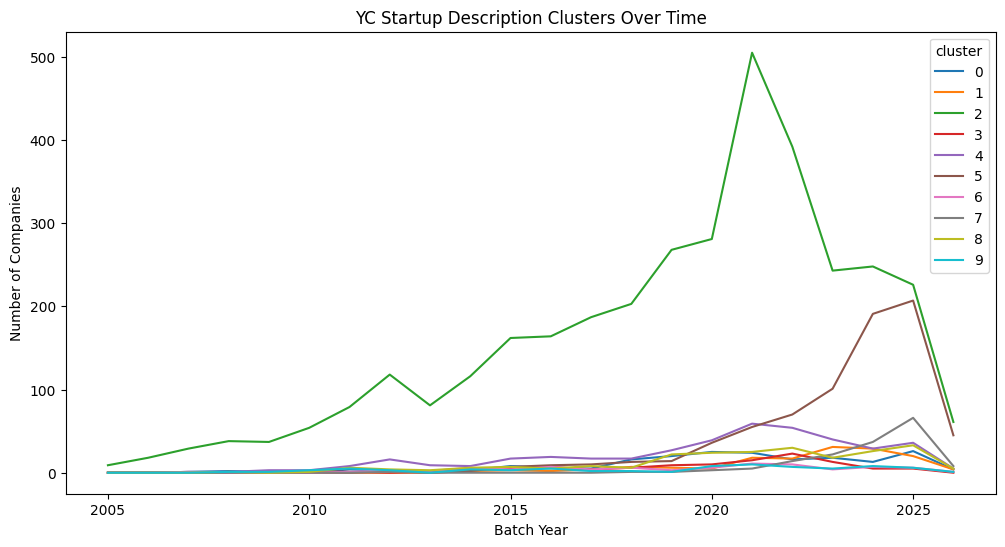

In [6]:
cluster_year = (
    df.groupby(["batch_year", "cluster"])
      .size()
      .reset_index(name="count")
)

pivot = (
    cluster_year
    .pivot(index="batch_year", columns="cluster", values="count")
    .fillna(0)
)

pivot.plot(figsize=(12,6))
plt.title("YC Startup Description Clusters Over Time")
plt.xlabel("Batch Year")
plt.ylabel("Number of Companies")
plt.show()


In [7]:
size_by_cluster = (
    df.dropna(subset=["company_size_num"])
      .groupby("cluster")["company_size_num"]
      .median()
      .sort_values(ascending=False)
)

size_by_cluster


cluster
4    12.0
3    10.0
6     9.0
2     7.0
0     6.0
8     6.0
1     5.0
5     4.0
9     4.0
7     3.0
Name: company_size_num, dtype: float64

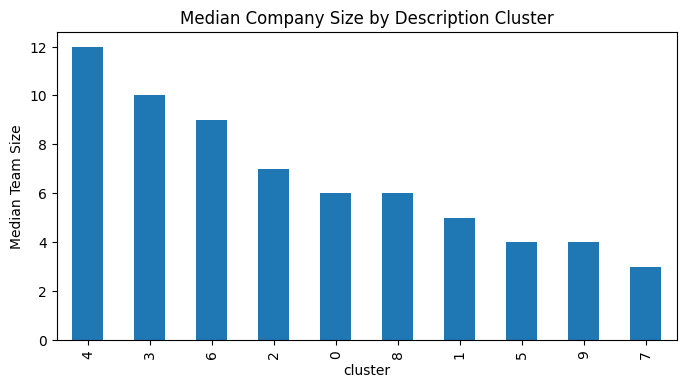

In [8]:
size_by_cluster.plot(kind="bar", figsize=(8,4))
plt.title("Median Company Size by Description Cluster")
plt.ylabel("Median Team Size")
plt.show()


In [9]:
bucket_dist = (
    df.groupby(["cluster", "company_size_bucket"])
      .size()
      .unstack(fill_value=0)
)

bucket_dist


company_size_bucket,early,large,scaling,small,solo
cluster,,,,,
0,38,11,17,124,6
1,34,3,6,103,2
2,944,193,330,1950,102
3,35,7,14,55,0
4,129,39,62,175,3
5,125,21,23,575,18
6,23,7,9,39,4
7,17,2,2,134,3
8,63,10,16,137,4


In [10]:
# ================================
# Cluster relabeling (standalone)
# ================================

CLUSTER_LABELS = {
    0: "AI Sales & Productivity",
    1: "AI Healthcare & Compliance",
    2: "Consumer & Marketplaces",
    3: "B2B SaaS & Management",
    4: "AI Platforms & Automation",
    5: "AI Agents & Copilots",
    6: "General Software / Infra",
    7: "AI Ops (Voice, Finance, Health)",
    8: "Data Platforms & Analytics",
    9: "AI Media & Creator Tools"
}

df["cluster_label"] = df["cluster"].map(CLUSTER_LABELS)


In [11]:
# =========================================
# Size bucket distribution by cluster label
# =========================================

bucket_dist_labeled = (
    df.groupby(["cluster_label", "company_size_bucket"])
      .size()
      .unstack(fill_value=0)
)

bucket_dist_labeled


company_size_bucket,early,large,scaling,small,solo
cluster_label,,,,,
AI Agents & Copilots,125,21,23,575,18
AI Healthcare & Compliance,34,3,6,103,2
AI Media & Creator Tools,17,2,4,50,2
"AI Ops (Voice, Finance, Health)",17,2,2,134,3
AI Platforms & Automation,129,39,62,175,3
AI Sales & Productivity,38,11,17,124,6
B2B SaaS & Management,35,7,14,55,0
Consumer & Marketplaces,944,193,330,1950,102
Data Platforms & Analytics,63,10,16,137,4


In [12]:
# =========================
# Total companies per cluster
# =========================

cluster_totals_labeled = bucket_dist_labeled.sum(axis=1)
cluster_totals_labeled.sort_values(ascending=False)


cluster_label
Consumer & Marketplaces            3519
AI Agents & Copilots                762
AI Platforms & Automation           408
Data Platforms & Analytics          230
AI Sales & Productivity             196
AI Ops (Voice, Finance, Health)     158
AI Healthcare & Compliance          148
B2B SaaS & Management               111
General Software / Infra             82
AI Media & Creator Tools             75
dtype: int64

In [13]:
# ==================================
# Normalize → probabilities per cluster
# ==================================

bucket_pct_labeled = bucket_dist_labeled.div(cluster_totals_labeled, axis=0)

bucket_pct_labeled["success_rate"] = (
    bucket_pct_labeled["scaling"] + bucket_pct_labeled["large"]
)

bucket_pct_labeled[["success_rate"]].sort_values("success_rate", ascending=False)


company_size_bucket,success_rate
cluster_label,
AI Platforms & Automation,0.247549
General Software / Infra,0.195122
B2B SaaS & Management,0.189189
Consumer & Marketplaces,0.148622
AI Sales & Productivity,0.142857
Data Platforms & Analytics,0.113043
AI Media & Creator Tools,0.080000
AI Healthcare & Compliance,0.060811
AI Agents & Copilots,0.057743


In [14]:
# ==================================
# Final proof table (counts + rates)
# ==================================

proof_table_labeled = (
    bucket_dist_labeled
    .assign(total_companies=cluster_totals_labeled)
    .join(bucket_pct_labeled[["success_rate"]])
    .sort_values("success_rate", ascending=False)
)

proof_table_labeled


company_size_bucket,early,large,scaling,small,solo,total_companies,success_rate
cluster_label,,,,,,,
AI Platforms & Automation,129,39,62,175,3,408,0.247549
General Software / Infra,23,7,9,39,4,82,0.195122
B2B SaaS & Management,35,7,14,55,0,111,0.189189
Consumer & Marketplaces,944,193,330,1950,102,3519,0.148622
AI Sales & Productivity,38,11,17,124,6,196,0.142857
Data Platforms & Analytics,63,10,16,137,4,230,0.113043
AI Media & Creator Tools,17,2,4,50,2,75,0.080000
AI Healthcare & Compliance,34,3,6,103,2,148,0.060811
AI Agents & Copilots,125,21,23,575,18,762,0.057743


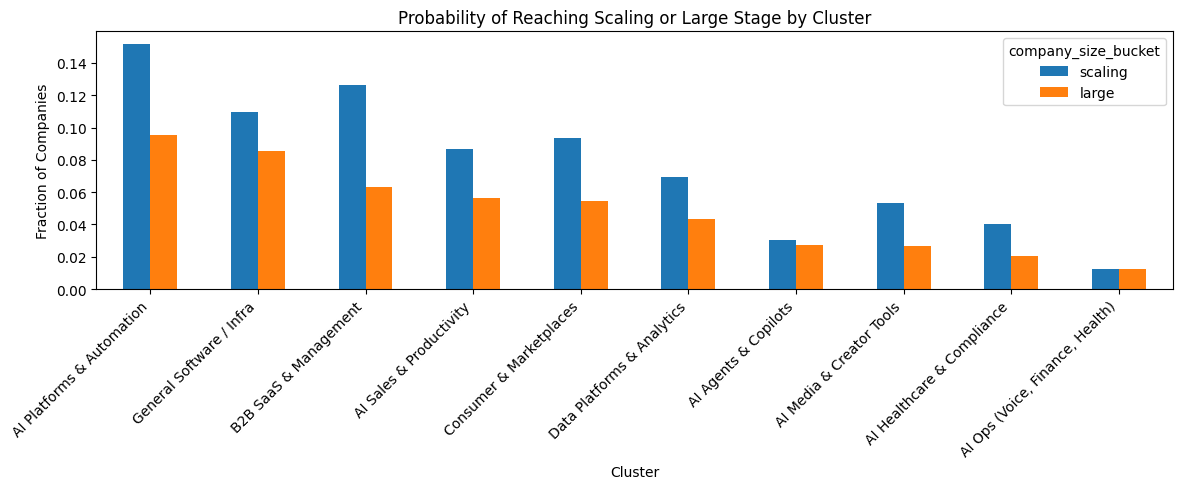

In [15]:
# =========================
# Visual proof
# =========================

(bucket_pct_labeled[["scaling", "large"]]
 .sort_values("large", ascending=False)
 .plot(kind="bar", figsize=(12,5)))

plt.title("Probability of Reaching Scaling or Large Stage by Cluster")
plt.ylabel("Fraction of Companies")
plt.xlabel("Cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Summary
 I use TfidfVectorizer to find clusters based on startups' descriptions.
- After getting the keywords, I manually label them.
- The goal of this analysis is to find what domains of startups are doing well, based on how they scale.
- The success rate of startups is still low. The top 3 domains are AI Platforms & Automation, General Software / Infra, and B2B SaaS & Management. They have a success rate from 0.189 to 0.248
- Consumer & Marketplaces have many early-stage startups. It is also the biggest cluster with the most companies. But they have a hard time scaling, and the success rate is still low.
- success rate here is also biased. Because some startups may choose to exist, sell, or get acquired before getting big or scaling